# Hiligaynon NER: Deep Error Diagnostics & Confusion Matrix

This notebook generates granular confusion matrices to expose semantic tagging boundaries. It is structured to help manually inspect and isolate misclassifications, heavily centering on the `ORG` vs `GPE` constraint overlap and the linguistic challenges introduced by Taglish (code-switching).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import sys
import joblib
import itertools
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

# Ensure parent directory is in path to import from 'training' module
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

print('Diagnostic libraries loaded.')

c:\Users\Dallas\Documents\Dallas\3rd Year - 2nd Sem\Natural Lanugage Processing\FINAL PROJECT\HiliTag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Diagnostic libraries loaded.


In [6]:
### 0. Load Converted Verified CoNLL Data

def load_conll_data(filepath):
    """Loads sentences and BIOES tags from a CoNLL-formatted file."""
    sentences = []
    sentence_labels = []
    
    if not os.path.exists(filepath):
        print(f"Warning: CoNLL file {filepath} not found.")
        return [], []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        words, labels = [], []
        for line in f:
            line = line.strip()
            if not line or line.startswith('-DOCSTART-'):
                if words:
                    sentences.append(words)
                    sentence_labels.append(labels)
                    words, labels = [], []
            else:
                splits = line.split()
                if len(splits) >= 2:
                    words.append(splits[0])
                    labels.append(splits[-1])
        if words:
            sentences.append(words)
            sentence_labels.append(labels)
    
    return sentences, sentence_labels

# Load test, train, and validation splits from converted_verified
converted_dir = os.path.join(os.getcwd(), '..', 'data', 'converted_verified')
print(f"Loading converted CoNLL files from: {converted_dir}\n")

test_sentences, test_labels = load_conll_data(os.path.join(converted_dir, 'dataset_test_final.conll'))
train_sentences, train_labels = load_conll_data(os.path.join(converted_dir, 'dataset_train_final.conll'))
val_sentences, val_labels = load_conll_data(os.path.join(converted_dir, 'dataset_val_final.conll'))

print(f"Test set: {len(test_sentences)} sentences, {sum(len(s) for s in test_sentences)} tokens")
print(f"Train set: {len(train_sentences)} sentences, {sum(len(s) for s in train_sentences)} tokens")
print(f"Val set: {len(val_sentences)} sentences, {sum(len(s) for s in val_sentences)} tokens")
print(f"\nUnique labels in test set: {sorted(set(label for labels in test_labels for label in labels))}")

Loading converted CoNLL files from: c:\Users\Dallas\Documents\Dallas\3rd Year - 2nd Sem\Natural Lanugage Processing\FINAL PROJECT\HiliTag\evaluation\..\data\converted_verified

Test set: 647 sentences, 13683 tokens
Train set: 5194 sentences, 109751 tokens
Val set: 647 sentences, 13704 tokens

Unique labels in test set: ['B-CARDINAL', 'B-DATE', 'B-EVENT', 'B-FAC', 'B-LANGUAGE', 'B-LAW', 'B-LOC', 'B-MONEY', 'B-ORDINAL', 'B-ORG', 'B-PERCENT', 'B-PERSON', 'B-PRODUCT', 'B-QUANTITY', 'B-TIME', 'B-WORK_OF_ART', 'E-CARDINAL', 'E-DATE', 'E-EVENT', 'E-FAC', 'E-LANGUAGE', 'E-LAW', 'E-LOC', 'E-MONEY', 'E-ORDINAL', 'E-ORG', 'E-PERCENT', 'E-PERSON', 'E-PRODUCT', 'E-QUANTITY', 'E-TIME', 'E-WORK_OF_ART', 'I-CARDINAL', 'I-DATE', 'I-EVENT', 'I-FAC', 'I-LAW', 'I-LOC', 'I-MONEY', 'I-ORDINAL', 'I-ORG', 'I-PERCENT', 'I-PERSON', 'I-PRODUCT', 'I-QUANTITY', 'I-TIME', 'I-WORK_OF_ART', 'O', 'S-CARDINAL', 'S-DATE', 'S-EVENT', 'S-FAC', 'S-GPE', 'S-LANGUAGE', 'S-LAW', 'S-LOC', 'S-MONEY', 'S-ORDINAL', 'S-ORG', 'S-PE

### 1. Generating the Heatmap

In [7]:
def plot_confusion_matrix(y_true, y_pred, classes, title='NER Confusion Matrix', cmap='Reds'):
    """Plots a seaborn heatmap of the classification confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=classes, yticklabels=classes, 
                cbar=False, linewidths=.5)
    
    plt.ylabel('True Labels', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Flatten test labels for analysis
y_true_flat = []
for labels in test_labels:
    y_true_flat.extend(labels)

unique_labels = sorted(set(y_true_flat))
print(f"Total test tokens: {len(y_true_flat)}")
print(f"Label distribution:")
for label in unique_labels:
    count = y_true_flat.count(label)
    pct = 100 * count / len(y_true_flat)
    print(f"  {label}: {count} ({pct:.1f}%)")

Total test tokens: 13683
Label distribution:
  B-CARDINAL: 11 (0.1%)
  B-DATE: 55 (0.4%)
  B-EVENT: 91 (0.7%)
  B-FAC: 1 (0.0%)
  B-LANGUAGE: 1 (0.0%)
  B-LAW: 13 (0.1%)
  B-LOC: 142 (1.0%)
  B-MONEY: 11 (0.1%)
  B-ORDINAL: 3 (0.0%)
  B-ORG: 18 (0.1%)
  B-PERCENT: 3 (0.0%)
  B-PERSON: 224 (1.6%)
  B-PRODUCT: 13 (0.1%)
  B-QUANTITY: 35 (0.3%)
  B-TIME: 16 (0.1%)
  B-WORK_OF_ART: 4 (0.0%)
  E-CARDINAL: 11 (0.1%)
  E-DATE: 55 (0.4%)
  E-EVENT: 91 (0.7%)
  E-FAC: 1 (0.0%)
  E-LANGUAGE: 1 (0.0%)
  E-LAW: 13 (0.1%)
  E-LOC: 142 (1.0%)
  E-MONEY: 11 (0.1%)
  E-ORDINAL: 3 (0.0%)
  E-ORG: 18 (0.1%)
  E-PERCENT: 3 (0.0%)
  E-PERSON: 224 (1.6%)
  E-PRODUCT: 13 (0.1%)
  E-QUANTITY: 35 (0.3%)
  E-TIME: 16 (0.1%)
  E-WORK_OF_ART: 4 (0.0%)
  I-CARDINAL: 2 (0.0%)
  I-DATE: 22 (0.2%)
  I-EVENT: 46 (0.3%)
  I-FAC: 1 (0.0%)
  I-LAW: 5 (0.0%)
  I-LOC: 82 (0.6%)
  I-MONEY: 2 (0.0%)
  I-ORDINAL: 3 (0.0%)
  I-ORG: 18 (0.1%)
  I-PERCENT: 3 (0.0%)
  I-PERSON: 142 (1.0%)
  I-PRODUCT: 4 (0.0%)
  I-QUANTITY: 36 (

Loading CRF Baseline Model...
Generating CRF Confusion Matrix...


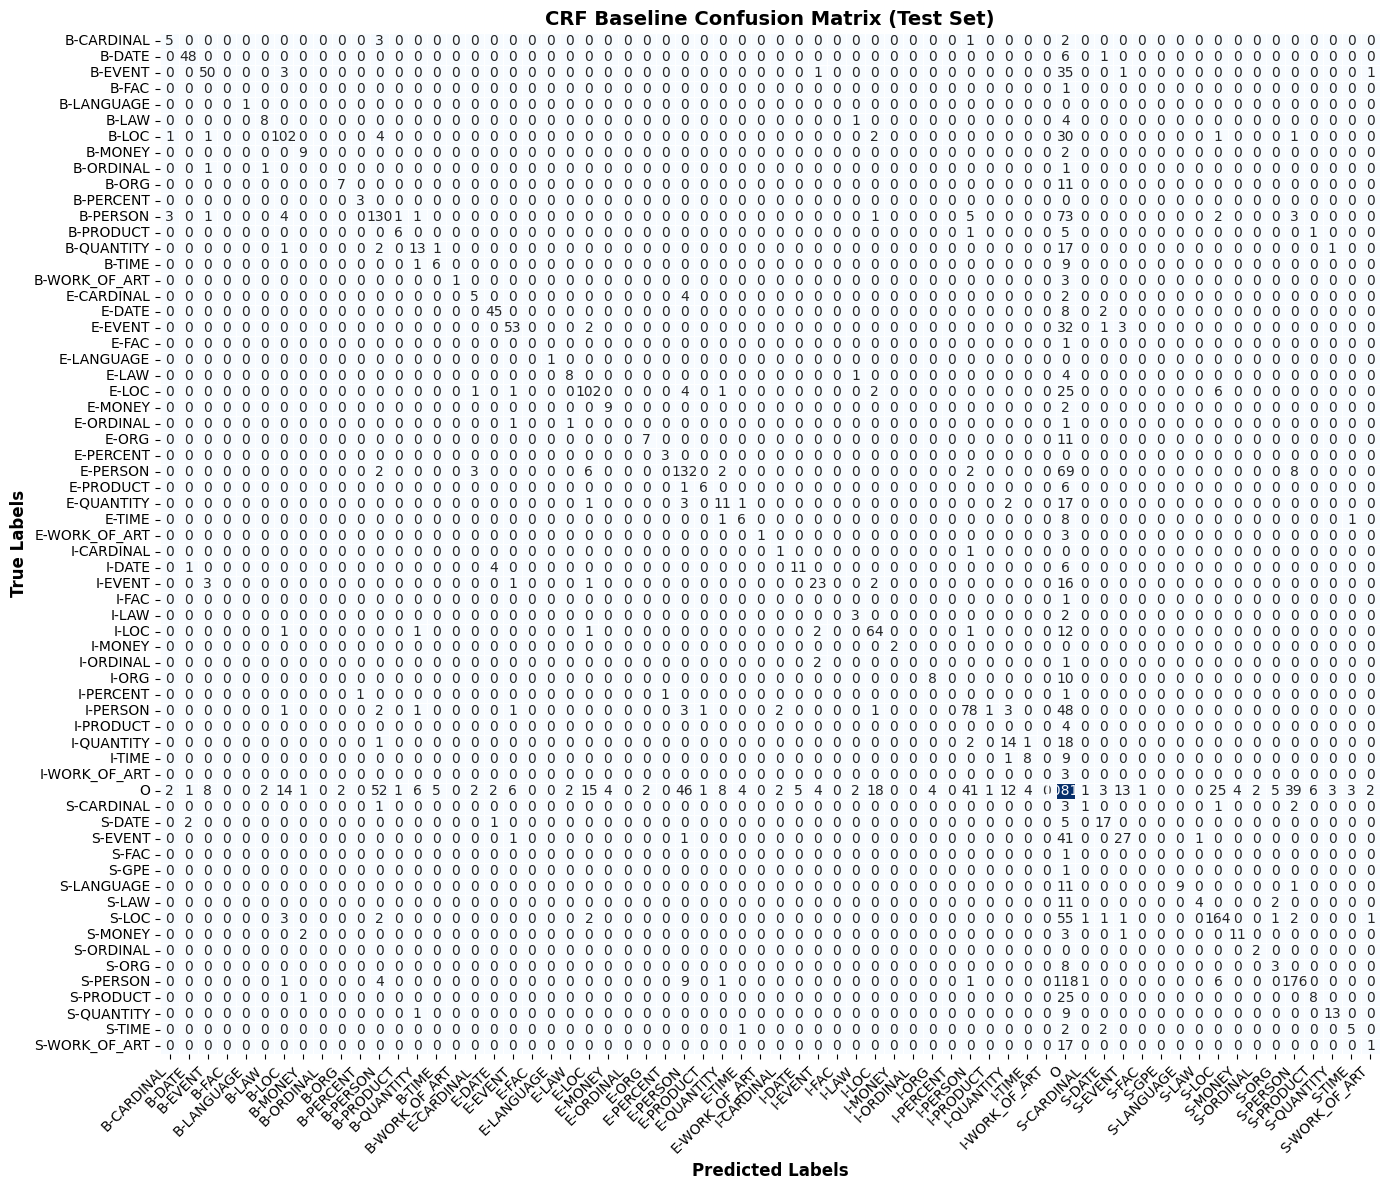

In [8]:
### 1.1 CRF Baseline Predictions & Heatmap
from training.model_crf_baseline import sent2features

crf_model_path = os.path.join('..', 'training', 'checkpoints', 'crf_baseline_model.joblib')

if os.path.exists(crf_model_path):
    print("Loading CRF Baseline Model...")
    crf = joblib.load(crf_model_path)
    
    # sent2features expects sentences where tokens are accessed via sent[i][0]
    X_test = [sent2features([[w] for w in s]) for s in test_sentences]
    y_pred_crf = crf.predict(X_test)
    
    y_pred_flat_crf = []
    for preds in y_pred_crf:
        y_pred_flat_crf.extend(preds)
        
    print("Generating CRF Confusion Matrix...")
    plot_confusion_matrix(y_true_flat, y_pred_flat_crf, unique_labels, title='CRF Baseline Confusion Matrix (Test Set)', cmap='Blues')
else:
    print(f"CRF Model not found at {crf_model_path}. Skipping CRF Heatmap.")

Loading XLM-RoBERTa Model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 589.46it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


Running inference on 647 test sentences...
Generating XLM-R Confusion Matrix...


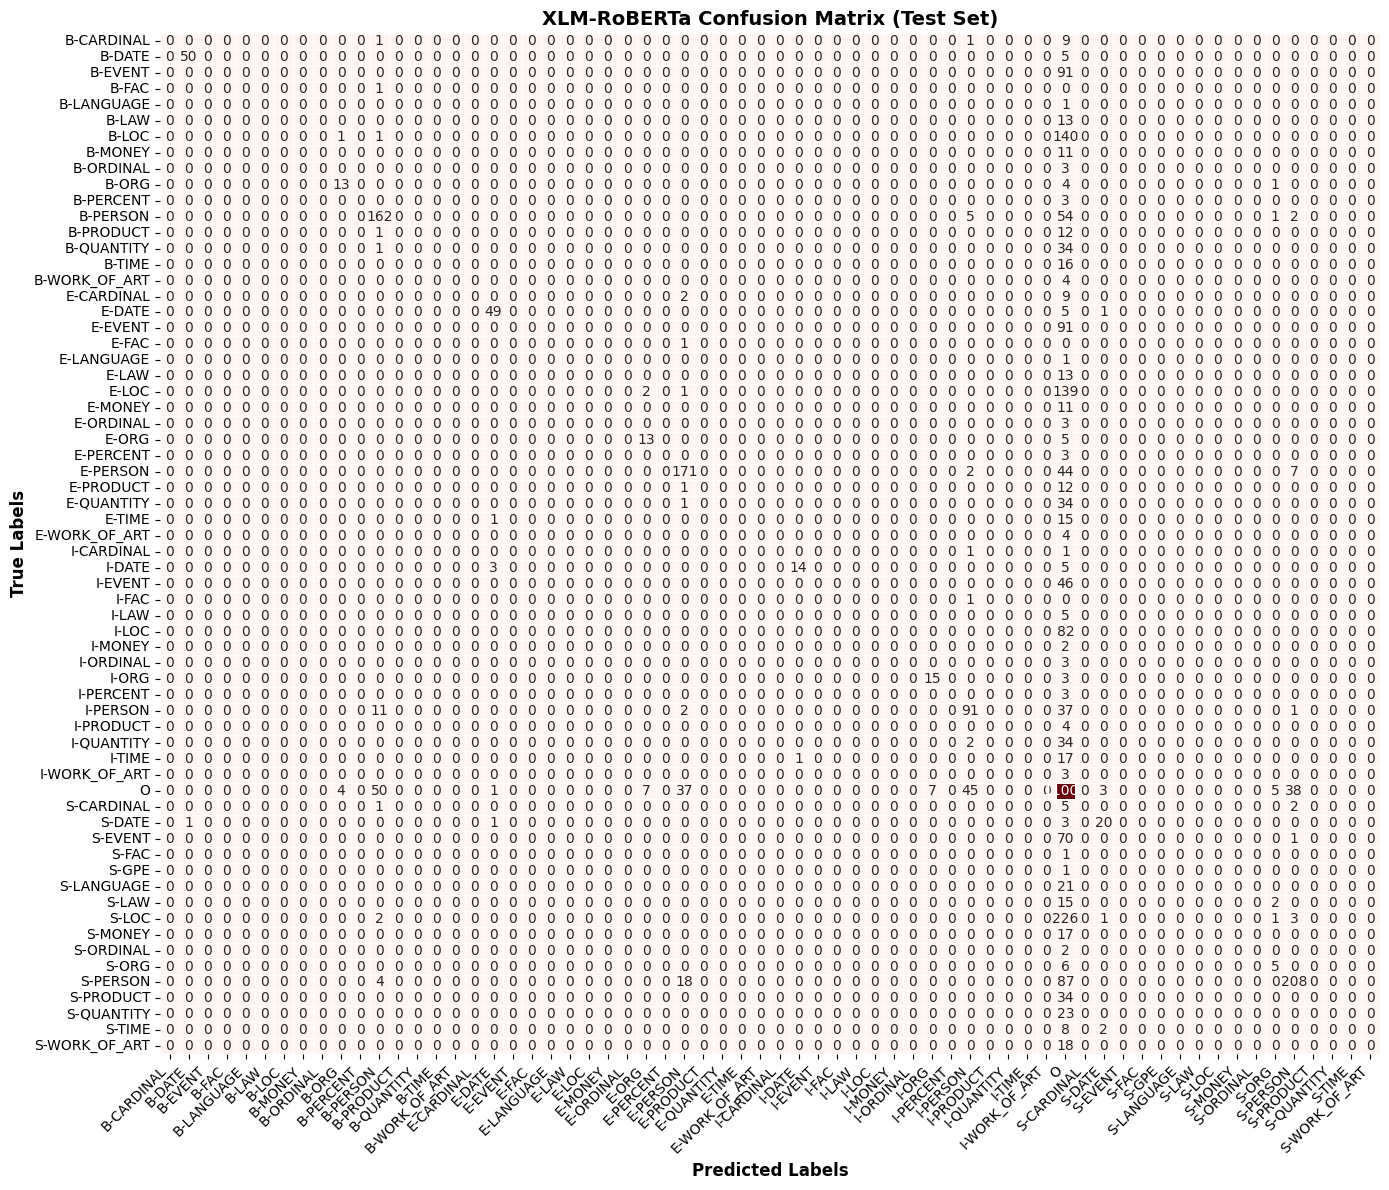

In [9]:
### 1.2 XLM-RoBERTa Predictions & Heatmap

xlm_model_path = os.path.join('..', 'training', 'checkpoints', 'best_model')

if os.path.exists(xlm_model_path):
    print("Loading XLM-RoBERTa Model...")
    tokenizer = AutoTokenizer.from_pretrained(xlm_model_path)
    model = AutoModelForTokenClassification.from_pretrained(xlm_model_path)
    nlp = pipeline("ner", model=model, tokenizer=tokenizer)
    
    y_pred_xlm = []
    print(f"Running inference on {len(test_sentences)} test sentences...")
    for idx, words in enumerate(test_sentences):
        # Reconstruct sentence text
        text = " ".join(words)
        ner_results = nlp(text)
        pred_labels = ['O'] * len(words)
        
        # Calculate character spans for original words to align predicted subwords
        word_spans = []
        curr_pos = 0
        for w in words:
            word_spans.append((curr_pos, curr_pos + len(w)))
            curr_pos += len(w) + 1
            
        for res in ner_results:
            start_char, end_char = res['start'], res['end']
            label = res['entity']
            # Map subword character offset back to the original word index
            for w_idx, (w_start, w_end) in enumerate(word_spans):
                if start_char >= w_start and start_char < w_end:
                    current_label = pred_labels[w_idx]
                    if current_label == 'O' or (current_label.startswith('I-') and label.startswith('B-')):
                        pred_labels[w_idx] = label
                    break
        y_pred_xlm.append(pred_labels)
        
    y_pred_flat_xlm = []
    for preds in y_pred_xlm:
        y_pred_flat_xlm.extend(preds)
        
    print("Generating XLM-R Confusion Matrix...")
    plot_confusion_matrix(y_true_flat, y_pred_flat_xlm, unique_labels, title='XLM-RoBERTa Confusion Matrix (Test Set)', cmap='Reds')
else:
    print(f"XLM-R Model not found at {xlm_model_path}. Skipping XLM-R Heatmap.")

### 2. Hunting Down Misclassifications (ORG vs GPE & Taglish)
The function below is designed to filter out exact sentences where a specific true tag is systematically predicted as a designated false tag.

In [10]:
def inspect_errors(sentences, true_labels, pred_labels, true_target='B-ORG', pred_target='B-GPE'):
    """
    Extracts contextual sentences where models confused true_target for pred_target.
    Used to identify systematic misclassifications (e.g., ORG vs GPE, Taglish code-mixing).
    """
    error_instances = []
    
    for sentence_idx, (words, t_tags, p_tags) in enumerate(zip(sentences, true_labels, pred_labels)):
        for word_idx, (word, t_tag, p_tag) in enumerate(zip(words, t_tags, p_tags)):
            if t_tag == true_target and p_tag == pred_target:
                context_start = max(0, word_idx - 2)
                context_end = min(len(words), word_idx + 3)
                context = " ".join(words[context_start:context_end])
                
                error_instances.append({
                    'sentence_idx': sentence_idx,
                    'word_idx': word_idx,
                    'word': word,
                    'context': context,
                    'true_tag': t_tag,
                    'pred_tag': p_tag
                })
    
    return error_instances

print("Error inspection functions ready.\n")

if 'y_pred_xlm' in locals():
    print("=== Analyzing XLM-RoBERTa ORG vs GPE Misclassifications ===")
    org_gpe_errors = inspect_errors(test_sentences, test_labels, y_pred_xlm, 'B-ORG', 'B-GPE')
    print(f"Found {len(org_gpe_errors)} instances where B-ORG was wrongly predicted as B-GPE.")
    for err in org_gpe_errors[:10]:
        print(f"Word: '{err['word']}' | True: {err['true_tag']} -> Pred: {err['pred_tag']}")
        print(f"Context: {err['context']}\n")
elif 'y_pred_crf' in locals():
    print("=== Analyzing CRF ORG vs GPE Misclassifications ===")
    org_gpe_errors = inspect_errors(test_sentences, test_labels, y_pred_crf, 'B-ORG', 'B-GPE')
    print(f"Found {len(org_gpe_errors)} instances where B-ORG was wrongly predicted as B-GPE.")
    for err in org_gpe_errors[:10]:
        print(f"Word: '{err['word']}' | True: {err['true_tag']} -> Pred: {err['pred_tag']}")
        print(f"Context: {err['context']}\n")
else:
    print("Run the model prediction cells above to populate pred_labels.")

Error inspection functions ready.

=== Analyzing XLM-RoBERTa ORG vs GPE Misclassifications ===
Found 0 instances where B-ORG was wrongly predicted as B-GPE.
